# ANALYSIS ON A CAFE SALES DATASET

In [5]:
# Importing all the necessary library for the analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# importing the dataset given
file_path = r"C:\Users\chukw\Downloads\cafe_sales.csv"
# Load CSV file into a DataFrame
df = pd.read_csv(file_path)
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2,4,Credit Card,Takeaway,9/8/2023
1,TXN_4977031,Cake,4,3,12,Cash,In-store,5/16/2023
2,TXN_4271903,Cookie,4,1,ERROR,Credit Card,In-store,7/19/2023
3,TXN_7034554,Salad,2,5,10,UNKNOWN,UNKNOWN,4/27/2023
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,6/11/2023
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2,4,NaN,UNKNOWN,8/30/2023
9996,TXN_9659401,NaN,3,NaN,3,Digital Wallet,NaN,6/2/2023
9997,TXN_5255387,Coffee,4,2,8,Digital Wallet,NaN,3/2/2023
9998,TXN_7695629,Cookie,3,NaN,3,Digital Wallet,NaN,12/2/2023


In [7]:
# checking the first 10 rows
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2,4,Credit Card,Takeaway,9/8/2023
1,TXN_4977031,Cake,4,3,12,Cash,In-store,5/16/2023
2,TXN_4271903,Cookie,4,1,ERROR,Credit Card,In-store,7/19/2023
3,TXN_7034554,Salad,2,5,10,UNKNOWN,UNKNOWN,4/27/2023
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,6/11/2023
5,TXN_2602893,Smoothie,5,4,20,Credit Card,NaN,3/31/2023
6,TXN_4433211,UNKNOWN,3,3,9,ERROR,Takeaway,10/6/2023
7,TXN_6699534,Sandwich,4,4,16,Cash,UNKNOWN,10/28/2023
8,TXN_4717867,NaN,5,3,15,NaN,Takeaway,7/28/2023
9,TXN_2064365,Sandwich,5,4,20,NaN,In-store,12/31/2023


In [8]:
# checking the lastt 10 rows
df.tail(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9990,TXN_1538510,Coffee,5,2,10,Digital Wallet,NaN,5/22/2023
9991,TXN_3897619,Sandwich,3,4,12,Cash,Takeaway,2/24/2023
9992,TXN_2739140,Smoothie,4,4,16,UNKNOWN,In-store,7/5/2023
9993,TXN_4766549,Smoothie,2,4,NaN,Cash,NaN,10/20/2023
9994,TXN_7851634,UNKNOWN,4,4,16,NaN,NaN,1/8/2023
9995,TXN_7672686,Coffee,2,2,4,NaN,UNKNOWN,8/30/2023
9996,TXN_9659401,NaN,3,NaN,3,Digital Wallet,NaN,6/2/2023
9997,TXN_5255387,Coffee,4,2,8,Digital Wallet,NaN,3/2/2023
9998,TXN_7695629,Cookie,3,NaN,3,Digital Wallet,NaN,12/2/2023
9999,TXN_6170729,Sandwich,3,4,12,Cash,In-store,11/7/2023


In [9]:
print("The total number of row and column")
df.shape

The total number of row and column


(10000, 8)

In [10]:
# Check info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


### Cleaning the Dataset

In [11]:
# checking for missing values
print("Checking for Missing Value: \n")
df.isnull().sum()

Checking for Missing Value: 



Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [12]:
# Checking for duplicate
df.duplicated().sum()

np.int64(0)

In [13]:
# Copy the dataset
df_new = df.copy()
df_new

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2,4,Credit Card,Takeaway,9/8/2023
1,TXN_4977031,Cake,4,3,12,Cash,In-store,5/16/2023
2,TXN_4271903,Cookie,4,1,ERROR,Credit Card,In-store,7/19/2023
3,TXN_7034554,Salad,2,5,10,UNKNOWN,UNKNOWN,4/27/2023
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,6/11/2023
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2,4,NaN,UNKNOWN,8/30/2023
9996,TXN_9659401,NaN,3,NaN,3,Digital Wallet,NaN,6/2/2023
9997,TXN_5255387,Coffee,4,2,8,Digital Wallet,NaN,3/2/2023
9998,TXN_7695629,Cookie,3,NaN,3,Digital Wallet,NaN,12/2/2023


In [14]:
# Drop rows with completely missing value
df_new.dropna(how = "all", subset = ["Quantity", "Price Per Unit", "Total Spent"])

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2,4,Credit Card,Takeaway,9/8/2023
1,TXN_4977031,Cake,4,3,12,Cash,In-store,5/16/2023
2,TXN_4271903,Cookie,4,1,ERROR,Credit Card,In-store,7/19/2023
3,TXN_7034554,Salad,2,5,10,UNKNOWN,UNKNOWN,4/27/2023
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,6/11/2023
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2,4,NaN,UNKNOWN,8/30/2023
9996,TXN_9659401,NaN,3,NaN,3,Digital Wallet,NaN,6/2/2023
9997,TXN_5255387,Coffee,4,2,8,Digital Wallet,NaN,3/2/2023
9998,TXN_7695629,Cookie,3,NaN,3,Digital Wallet,NaN,12/2/2023


In [15]:
#Checking the data type
df_new.dtypes

Transaction ID      object
Item                object
Quantity            object
Price Per Unit      object
Total Spent         object
Payment Method      object
Location            object
Transaction Date    object
dtype: object

In [16]:
# Convert Columns to Numeric
df_new['Quantity'] = pd.to_numeric(df_new['Quantity'], errors = "coerce")
df_new['Price Per Unit'] = pd.to_numeric(df_new['Price Per Unit'], errors = "coerce")
df_new['Total Spent'] = pd.to_numeric(df_new['Total Spent'], errors = "coerce")

#Convert Transation column to Proper Date column 
df_new['Transaction Date'] = (
    df_new['Transaction Date']
    .astype(str)
    .str.strip()
    .replace(['', 'N/A', 'null', 'None', 'nan'], pd.NA)
)

# Step 2: Convert (auto detect)
df_new['Transaction Date'] = pd.to_datetime(
    df_new['Transaction Date'], 
    errors="coerce"
)

# Droping any NaT value in the transaction column after conversation
df_new.dropna(subset = ['Transaction Date'], inplace = True)

In [17]:
df_new.dtypes 

Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

In [18]:
# Recalculate missing values using relationship
# Total_spent = Quantity * Price Per Unit
df_new.loc[df_new['Total Spent'].isna(), 'Total Spent'] = (
    df_new['Quantity'] * df_new['Price Per Unit']
)

# Quantity = Total_spent / Price per unit
df_new.loc[df_new['Quantity'].isna(), 'Quantity'] = (
    df_new['Total Spent'] / df_new['Price Per Unit']
)

# Price per unit = Total_spent / Quantity
df_new.loc[df_new['Price Per Unit'].isna(), 'Price Per Unit'] = (
    df_new['Total Spent'] / df_new['Quantity']
)

# Drop the remaining columns that either of the two values are missing
df_new.dropna(how = "any", subset = ["Quantity", "Price Per Unit", "Total Spent"], inplace = True)


df_new

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3.0,1.0,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-12-02


In [19]:
# Getting the most occurring location, item and payment from the categorical columns
#df_new[["Location", 'Item', 'Payment Method']].mode()

# Calculate modes
location_mode = df_new['Location'].mode()[0]
item_mode = df_new['Item'].mode()[0] 
payment_mode = df_new['Payment Method'].mode()[0]

# Fill missing values safely
df_new.loc[:, 'Location'] = df_new['Location'].fillna(location_mode)
df_new.loc[:, 'Item'] = df_new['Item'].fillna(item_mode)
df_new.loc[:, 'Payment Method'] = df_new['Payment Method'].fillna(payment_mode)

df_new

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Digital Wallet,UNKNOWN,2023-08-30
9996,TXN_9659401,Juice,3.0,1.0,3.0,Digital Wallet,Takeaway,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway,2023-03-02
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,Takeaway,2023-12-02


In [20]:
#Checcking for UKNOWN & ERROR values in the payment, item and Location columns 
((df_new == "UNKNOWN") | (df_new == "ERROR")).sum()

Transaction ID        0
Item                608
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method      571
Location            658
Transaction Date      0
dtype: int64

In [21]:
#Converting the UNKNOWN & ERROR value to NaN
df_new.replace(["UNKNOWN", "ERROR"], np.nan, inplace = True)

#Filling them with Proper categorical missing value "Unknown"
df_new['Item'].fillna("Unknown")
df_new['Payment Method'].fillna("Unknown")
df_new['Location'].fillna("Unknown")

df_new

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Digital Wallet,NaN,2023-08-30
9996,TXN_9659401,Juice,3.0,1.0,3.0,Digital Wallet,Takeaway,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway,2023-03-02
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,Takeaway,2023-12-02


In [22]:
#Checking if their is a null value remaining in the dataset
df_new.isnull().sum()

Transaction ID        0
Item                608
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method      571
Location            658
Transaction Date      0
dtype: int64

In [23]:
# Creating a new columns from the Transaction colunm.
#Creating Month, Day and DayOfWeek
df_new["Month"] = df_new['Transaction Date'].dt.month
df_new["Day"] = df_new['Transaction Date'].dt.day
df_new["DayOfWeek"] = df_new["Transaction Date"].dt.day_name()

df_new

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month,Day,DayOfWeek
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,9,8,Friday
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,5,16,Tuesday
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,7,19,Wednesday
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27,4,27,Thursday
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,6,11,Sunday
...,...,...,...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Digital Wallet,NaN,2023-08-30,8,30,Wednesday
9996,TXN_9659401,Juice,3.0,1.0,3.0,Digital Wallet,Takeaway,2023-06-02,6,2,Friday
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway,2023-03-02,3,2,Thursday
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,Takeaway,2023-12-02,12,2,Saturday


### Visualization of the dataset according to various compairsion

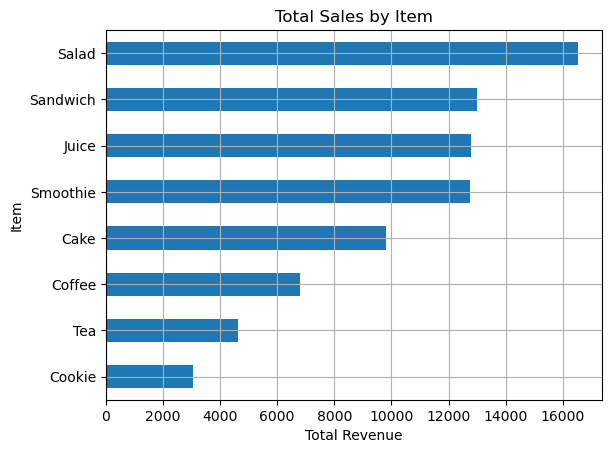

In [24]:
# Sales by item
# best selling product and revenue drivers
df_new.groupby('Item')['Total Spent'].sum().sort_values().plot(kind = 'barh')
plt.title('Total Sales by Item')
plt.xlabel('Total Revenue')
plt.ylabel('Item')
plt.grid()
plt.show()

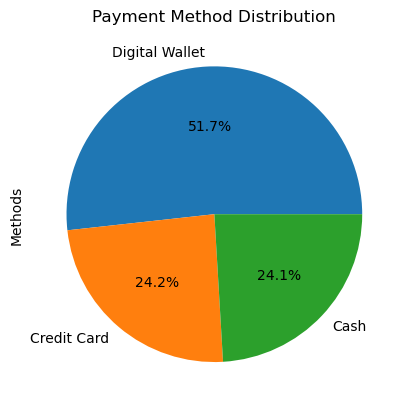

In [25]:
# Payment Method
df_new['Payment Method'].value_counts().plot(kind = 'pie', autopct = '%1.1f%%')
plt.title('Payment Method Distribution')
plt.ylabel('Methods')
plt.show()

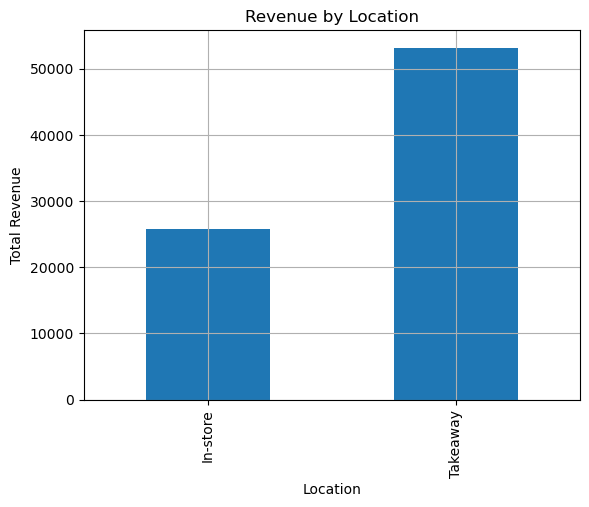

In [26]:
# Location and Revenue
df_new.groupby('Location')['Total Spent'].sum().sort_values().plot(kind = 'bar')
plt.title('Revenue by Location')
plt.ylabel('Total Revenue')
plt.xlabel('Location')
plt.grid()
plt.show()

In [48]:
df_new.groupby('Month')['Total Spent'].sum().sort_values()

Month
2     6626.0
9     6842.0
7     6876.5
5     6916.5
11    6957.0
8     7049.5
12    7153.0
4     7168.0
3     7190.5
1     7219.0
10    7295.0
6     7350.0
Name: Total Spent, dtype: float64

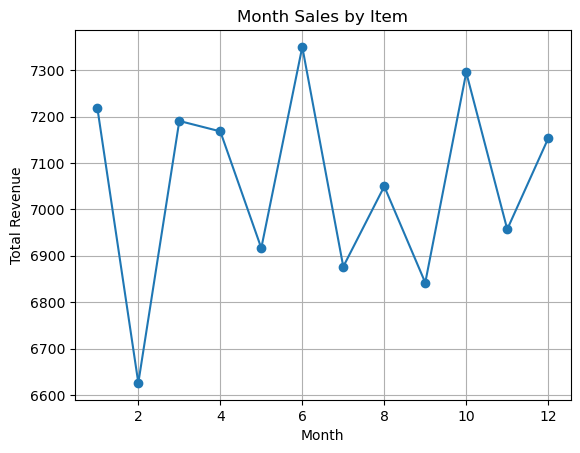

In [27]:
df_new.groupby('Month')['Total Spent'].sum().plot(marker = 'o')
plt.title('Month Sales by Item')
plt.ylabel('Total Revenue')
plt.xlabel('Month')
plt.grid()
plt.show()

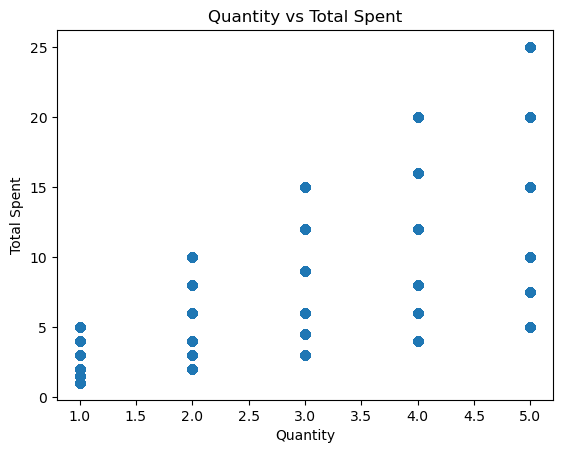

In [28]:
#'Quantity vs Total Spent
plt.scatter(df_new['Quantity'], df_new['Total Spent'])
plt.title('Quantity vs Total Spent')
plt.ylabel('Total Spent')
plt.xlabel('Quantity')
plt.show()

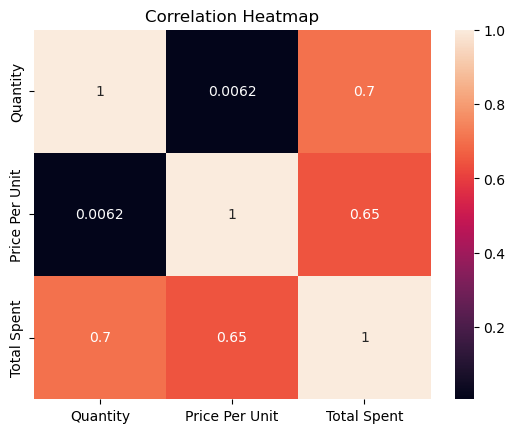

In [29]:
# Heatmap
# Finding the correlation between all values
corr = df_new[['Quantity', 'Price Per Unit', 'Total Spent']].corr()
sns.heatmap(corr, annot =True)
plt.title('Correlation Heatmap')
plt.show()

### Building a Machine Learning Model

In [70]:
#Import all the necessary model from sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

df_new['QxP'] = df_new['Quantity'] * df_new['Price Per Unit']

# Feature and Target
X = df_new[['Quantity', 'Price Per Unit', 'Month', 'QxP']]
y = df_new['Total Spent']

#Spliting the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   test_size = 0.2, # 20% for testing
                                                   random_state = 42 # makes results repeatable
                                                   )
#Creating a linear regression model for the train data
model = RandomForestRegressor(n_estimators = 200, 
                              max_depth = 10,
                              random_state = 42)
model.fit(X_train, y_train)

#prediction of the model
y_pred = model.predict(X_test)
print("Predictions:", y_pred)
print("Actual:", y_test)

Predictions: [20.  5. 16. ... 15.  5. 12.]
Actual: 2910    20.0
8649     5.0
7749    16.0
6285    20.0
7550     9.0
        ... 
4744     5.0
893      7.5
8731    15.0
6396     5.0
3171    12.0
Name: Total Spent, Length: 1897, dtype: float64


R2 score: 1.0
RMSE: 0.0


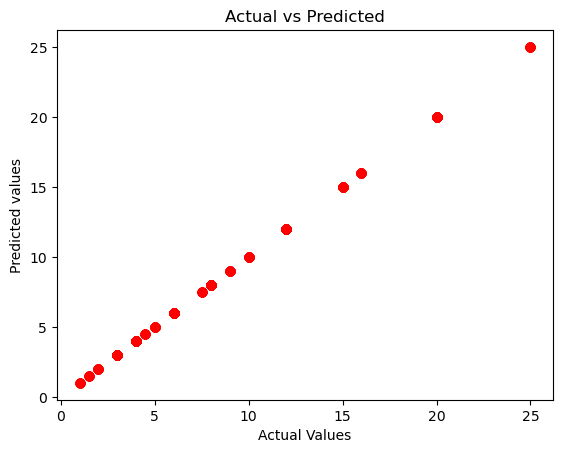

In [71]:
# Model Evaluation
score = r2_score(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
print("R2 score:", score)
print("RMSE:", RMSE)

# Visualize Performance
plt.scatter(y_test, y_pred, c = 'r')
plt.title('Actual vs Predicted')
plt.ylabel('Predicted values')
plt.xlabel('Actual Values')
plt.show()

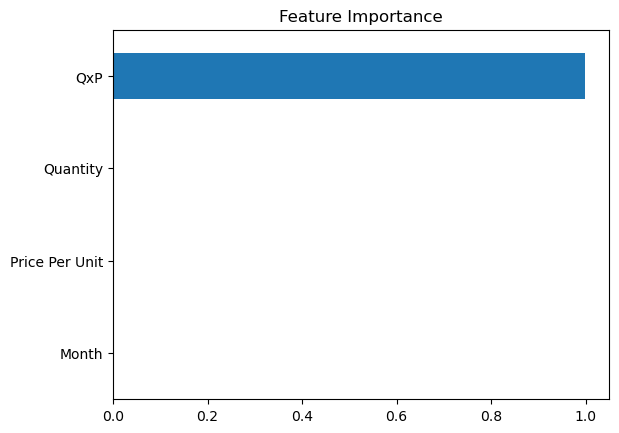

In [77]:
# Feature Importance
importance = pd.Series(model.feature_importances_, index = X.columns)
importance.sort_values().plot(kind = 'barh')
plt.title('Feature Importance')  
plt.show()

### Creating User input for future prediction

In [76]:
# user input to predict the future of total money spent
Quantity = float(input('Enter Quantity:'))
Price_Per_Unit = float(input('Enter Price Per Unit:'))
Month= int(input('Enter Month'))
QxP = Quantity * Price_Per_Unit

new_data = pd.DataFrame([[Quantity, Price_Per_Unit, Month, QxP]], 
                        columns =   ['Quantity', 'Price Per Unit', 'Month', 'QxP'])

predictions = model.predict(new_data)
print("Predicted Total Spent:", predictions[0])

Enter Quantity: 6
Enter Price Per Unit: 7
Enter Month 2


Predicted Total Spent: 25.0


In [78]:
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']

In [12]:
import os
os.getcwd()

'C:\\Users\\chukw'

In [14]:
readme = """
# ☕ Cafe Sales Prediction App

![Python](https://img.shields.io/badge/Python-3.11-blue?style=for-the-badge&logo=python)
![Streamlit](https://img.shields.io/badge/Streamlit-App-red?style=for-the-badge&logo=streamlit)
![Scikit-Learn](https://img.shields.io/badge/Scikit--Learn-ML-orange?style=for-the-badge&logo=scikit-learn)
![Pandas](https://img.shields.io/badge/Pandas-Data%20Analysis-black?style=for-the-badge&logo=pandas)

---

# 📌 Project Overview

This project is a machine learning application that predicts the total amount spent by customers in a cafe using historical sales data.

The project includes:

- Data cleaning and preprocessing
- Feature engineering
- Machine learning model training
- Model serialization using Joblib
- Interactive Streamlit web application

---

# 🚀 Technologies Used

| Technology | Purpose |
|---|---|
| Python | Programming Language |
| Pandas | Data Analysis |
| Scikit-learn | Machine Learning |
| Streamlit | Web App |
| Joblib | Model Saving |
| Jupyter Notebook | Development Environment |

---

# 🧠 Machine Learning Model

The predictive model was built using:

```python
RandomForestRegressor
```

The trained model was saved using:

```python
joblib
```

---

# 📊 Features

✅ Missing value handling  
✅ Feature engineering  
✅ Predictive analytics  
✅ Streamlit dashboard  
✅ Interactive user input  
✅ Model deployment ready  

---

# 📂 Project Structure

```text
cafe-sales-prediction/
│
├── Cafe_Sales_Prediction.ipynb
├── cafe.py
├── model.pkl
├── requirements.txt
├── README.md
├── .gitignore
```

---

# ▶️ How to Run the Project

## 1️⃣ Clone the repository

```bash
git clone https://github.com/onyeiwu/cafe-sales-prediction.git

```

---

## 2️⃣ Navigate into the project folder

```bash
cd cafe-sales-prediction
```

---

## 3️⃣ Install dependencies

```bash
pip install -r requirements.txt
```

---

## 4️⃣ Run the Streamlit application

```bash
streamlit run cafe.py
```

---

# 📸 Project Screenshots

## Streamlit App Interface

Add your screenshot here after uploading:

```markdown
![App Screenshot](images/app.png)
```

---

# 📈 Future Improvements

- Add visualization dashboard
- Deploy to Streamlit Cloud
- Add model evaluation metrics
- Add advanced feature engineering
- Improve UI design

---

# 👨‍💻 Author

## Gabriel Onyeiwu

- Data Analyst
- Machine Learning Enthusiast
- Python Developer

---

# ⭐ Support

If you like this project, consider giving it a ⭐ on GitHub!
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("README.md created successfully")

README.md created successfully


In [15]:
requirements = """
pandas
numpy
scikit-learn
streamlit
joblib
jupyter
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created")

requirements.txt created


In [16]:
gitignore = """
__pycache__/
.ipynb_checkpoints/
*.pyc
venv/
"""

with open(".gitignore", "w") as f:
    f.write(gitignore)

print(".gitignore created")

.gitignore created
